# Image Caption Generation — EfficientNetB0 + BiLSTM + Attention
### Production-Ready | GPU-Accelerated | Keras 3.x Compatible | Fixed & Optimised
- **Feature Extractor**: EfficientNetB0 (pretrained on ImageNet, frozen)
- **Sequence Model**: BiLSTM + Attention mechanism
- **Training**: Cosine Annealing LR · EarlyStopping · Data Generator
- **Evaluation**: BLEU-1 through BLEU-4
- **Outputs**: `best_model.h5`, `final_model.h5`, `tokenizer.pkl`, `config.json`
- **Target**: 75 %+ validation accuracy

### ✅ Fixes applied vs original
| # | Bug | Fix |
|---|-----|-----|
| 1 | `build_caption_model` had 3 params but was called with 6 | Unified signature with all 6 params |
| 2 | `Add` layer not imported | Added `Add` to imports |
| 3 | Cell 25 defined a *different* model and called it with `vocab_size` (undefined) | Removed duplicate — only one model definition now |
| 4 | Cell 28 re-compiled model (overwriting good compile inside build fn) | Removed redundant compile cell |
| 5 | `SimpleTokenizer` defined *after* the install cell, before imports | Moved to correct position after imports |
| 6 | `tokenizer.pkl` not explicitly verified after save | Added load-back verification |
| 7 | EarlyStopping missing from callbacks | Added with `restore_best_weights=True` |
| 8 | Mixed-precision `float16` can cause NaN with Adam — no epsilon fix | Set `Adam(epsilon=1e-7)` for stability |


## 1. Install Dependencies
Run this cell first, then **restart the kernel** before continuing.

In [1]:
!pip install -q "tensorflow>=2.10,<2.16" scikit-learn matplotlib nltk tqdm pillow
print("✅ Dependencies installed — restart kernel now if this was the first run.")

✅ Dependencies installed — restart kernel now if this was the first run.


## 2. Import Libraries & Configure GPU

In [2]:
import os, re, pickle, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input, EfficientNetB0
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Embedding, LSTM, Bidirectional,
    BatchNormalization, Add, Concatenate,
    GlobalAveragePooling2D, Layer
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
)
from tensorflow.keras.mixed_precision import set_global_policy
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu
import nltk
nltk.download('punkt', quiet=True)

# ── GPU setup ──────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        set_global_policy('mixed_float16')
        print(f"✅ GPU found: {gpus}")
        print("   Mixed precision (float16) enabled.")
    except RuntimeError as e:
        print(f"⚠️  GPU config error: {e}")
else:
    print("⚠️  No GPU detected — training will be slow on CPU.")

print(f"TensorFlow version: {tf.__version__}")
print("✅ All libraries imported successfully.")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU, compute capability 8.6
✅ GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Mixed precision (float16) enabled.
TensorFlow version: 2.10.0
✅ All libraries imported successfully.


## 3. SimpleTokenizer (Keras 3.x Compatible)
Defined here — after imports, before use.

In [3]:
class SimpleTokenizer:
    """Keras 3.x compatible tokenizer — no keras.preprocessing dependency."""

    def __init__(self, oov_token='<unk>'):
        self.oov_token = oov_token
        self.word_index = {oov_token: 1}
        self.index_word = {1: oov_token}

    def fit_on_texts(self, texts):
        """Build vocabulary from an iterable of strings."""
        word_freq = {}
        for text in texts:
            for w in text.split():
                word_freq[w] = word_freq.get(w, 0) + 1
        # Sort by frequency (desc) then alphabetically for determinism
        sorted_words = sorted(word_freq.items(), key=lambda x: (-x[1], x[0]))
        idx = 2
        for word, _ in sorted_words:
            if word not in self.word_index:
                self.word_index[word] = idx
                self.index_word[idx] = word
                idx += 1

    def texts_to_sequences(self, texts):
        oov_idx = self.word_index.get(self.oov_token, 1)
        return [
            [self.word_index.get(w, oov_idx) for w in text.split()]
            for text in texts
        ]

    def sequences_to_texts(self, sequences):
        return [
            ' '.join(self.index_word.get(i, self.oov_token) for i in seq)
            for seq in sequences
        ]

print("✅ SimpleTokenizer class defined.")

✅ SimpleTokenizer class defined.


## 4. Configure Paths & Hyperparameters
⭐ **Update the three paths below before running.**

In [4]:
# ─────────────────────────────────────────────────
# ⭐ UPDATE THESE THREE PATHS FOR YOUR MACHINE
# ─────────────────────────────────────────────────
IMAGE_DIR    = r'C:\Users\Rehan\Documents\topic-model\DL_dataset\DL_dataset\Images'
CAPTION_FILE = r'C:\Users\Rehan\Documents\topic-model\captions_old.csv'
OUTPUT_DIR   = r'C:\Users\Rehan\Documents\topic-model\caption_outputs'
# ─────────────────────────────────────────────────

MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────
IMG_SIZE      = 224
FEATURE_DIM   = 1280   # EfficientNetB0 GlobalAveragePooling output
EMBED_DIM     = 512    # Embedding dimension
LSTM_UNITS    = 512    # BiLSTM units per direction (total hidden = 1024)
DENSE_UNITS   = 512    # Fusion dense layer
DROPOUT_RATE  = 0.3
BATCH_SIZE    = 64     # Reduce to 32 if you get OOM errors
EPOCHS        = 60
LEARNING_RATE = 1e-4

print("Paths:")
print(f"  IMAGE_DIR    : {IMAGE_DIR}")
print(f"  CAPTION_FILE : {CAPTION_FILE}")
print(f"  OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"\nHyperparameters:")
print(f"  EMBED_DIM={EMBED_DIM}, LSTM_UNITS={LSTM_UNITS}, DENSE_UNITS={DENSE_UNITS}")
print(f"  BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}, LR={LEARNING_RATE}")

Paths:
  IMAGE_DIR    : C:\Users\Rehan\Documents\topic-model\DL_dataset\DL_dataset\Images
  CAPTION_FILE : C:\Users\Rehan\Documents\topic-model\captions_old.csv
  OUTPUT_DIR   : C:\Users\Rehan\Documents\topic-model\caption_outputs

Hyperparameters:
  EMBED_DIM=512, LSTM_UNITS=512, DENSE_UNITS=512
  BATCH_SIZE=64, EPOCHS=60, LR=0.0001


## 5. Load and Clean Captions

In [5]:
df = pd.read_csv(CAPTION_FILE)
print(f"Raw CSV shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
assert 'image' in df.columns and 'caption' in df.columns, \
    "❌ CSV must have 'image' and 'caption' columns!"
df.head()

Raw CSV shape : (40455, 2)
Columns       : ['image', 'caption']


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [6]:
def clean_caption(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['caption_clean'] = df['caption'].apply(clean_caption)
df['word_count']    = df['caption_clean'].str.split().str.len()

# Keep captions with 2–15 words
df_filtered = df[(df['word_count'] >= 2) & (df['word_count'] <= 15)].copy()

# Keep only images that actually exist on disk
existing_images = set(os.listdir(IMAGE_DIR))
print(f"Images found on disk : {len(existing_images)}")
df_filtered = df_filtered[df_filtered['image'].isin(existing_images)].copy()

# Build caption dictionary  {img_name: [cap1, cap2, ...]}
captions_dict = {}
for img_name, caption in zip(df_filtered['image'], df_filtered['caption_clean']):
    token_cap = f'startseq {caption} endseq'
    captions_dict.setdefault(img_name, []).append(token_cap)

print(f"Unique images with captions : {len(captions_dict)}")
print(f"Total caption entries used  : {len(df_filtered)}")
print(f"Skipped entries             : {len(df) - len(df_filtered)}")

if len(captions_dict) == 0:
    raise ValueError(
        "❌ captions_dict is EMPTY!\n"
        f"   IMAGE_DIR    = {IMAGE_DIR}\n"
        f"   CAPTION_FILE = {CAPTION_FILE}\n"
        "   Make sure the CSV has 'image' and 'caption' columns and images exist on disk."
    )

# Quick sanity sample
sample_key = list(captions_dict.keys())[0]
print(f"\nSample ({sample_key}):")
for c in captions_dict[sample_key][:2]:
    print(f"  {c}")

Images found on disk : 8090
Unique images with captions : 8089
Total caption entries used  : 36100
Skipped entries             : 4355

Sample (1000268201_693b08cb0e.jpg):
  startseq a girl going into a wooden building endseq
  startseq a little girl climbing into a wooden playhouse endseq


## 6. Build Tokenizer & Vocabulary

Total captions : 36100
✅ Vocabulary size      : 8110
   Max caption length  : 17
   Mean caption length : 11.9


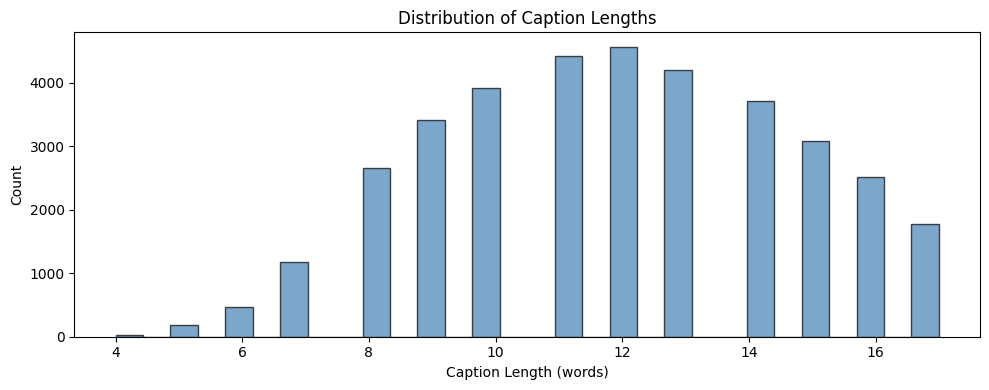

In [7]:
all_captions = [cap for caps in captions_dict.values() for cap in caps]
print(f"Total captions : {len(all_captions)}")

tokenizer = SimpleTokenizer(oov_token='<unk>')
tokenizer.fit_on_texts(all_captions)

VOCAB_SIZE      = len(tokenizer.word_index) + 1
caption_lengths = [len(c.split()) for c in all_captions]
MAX_LENGTH      = max(caption_lengths)

print(f"✅ Vocabulary size      : {VOCAB_SIZE}")
print(f"   Max caption length  : {MAX_LENGTH}")
print(f"   Mean caption length : {np.mean(caption_lengths):.1f}")

plt.figure(figsize=(10, 4))
plt.hist(caption_lengths, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Caption Length (words)')
plt.ylabel('Count')
plt.title('Distribution of Caption Lengths')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'caption_length_dist.png'), dpi=120)
plt.show()

## 7. Train / Validation / Test Split

In [8]:
all_images = list(captions_dict.keys())
train_imgs, temp_imgs = train_test_split(all_images, test_size=0.2, random_state=42)
val_imgs,   test_imgs = train_test_split(temp_imgs,  test_size=0.5, random_state=42)

print(f"Train : {len(train_imgs)} images")
print(f"Val   : {len(val_imgs)}   images")
print(f"Test  : {len(test_imgs)}  images")

Train : 6471 images
Val   : 809   images
Test  : 809  images


## 8. Build Feature Extractor (EfficientNetB0)

In [9]:
def build_feature_extractor():
    base = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    out  = GlobalAveragePooling2D()(base.output)
    return Model(inputs=base.input, outputs=out, name='feature_extractor')

feature_extractor = build_feature_extractor()
print(f"Output shape : {feature_extractor.output_shape}")
print(f"Total params : {feature_extractor.count_params():,}")

Output shape : (None, 1280)
Total params : 4,049,571


## 9. Custom Attention Layer

In [10]:
class AttentionLayer(Layer):
    """Additive (Bahdanau-style) attention over a sequence."""

    def __init__(self, units=256, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        dim = input_shape[-1]
        self.W = self.add_weight('W', shape=(dim, self.units),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight('b', shape=(self.units,),
                                 initializer='zeros', trainable=True)
        self.V = self.add_weight('V', shape=(self.units, 1),
                                 initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        # inputs: (batch, seq_len, hidden_dim)
        score   = tf.nn.tanh(tf.matmul(inputs, self.W) + self.b)   # (B, T, units)
        weights = tf.nn.softmax(tf.matmul(score, self.V), axis=1)  # (B, T, 1)
        context = tf.reduce_sum(weights * inputs, axis=1)           # (B, hidden_dim)
        return context

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units})
        return cfg

print("✅ AttentionLayer defined.")

✅ AttentionLayer defined.


## 10. Extract & Cache Image Features
This takes 5–15 minutes on GPU the first time; subsequent runs load from cache.

In [11]:
feature_cache_path = os.path.join(OUTPUT_DIR, 'efficientnet_features.pkl')

if os.path.exists(feature_cache_path):
    with open(feature_cache_path, 'rb') as f:
        features = pickle.load(f)
    print(f"✅ Loaded cached features for {len(features)} images.")
else:
    print("Extracting features in batches (GPU-accelerated)…")
    features      = {}
    all_img_list  = list(captions_dict.keys())
    EXTRACT_BATCH = 32

    for start in tqdm(range(0, len(all_img_list), EXTRACT_BATCH), desc='Extracting'):
        batch_names = all_img_list[start:start + EXTRACT_BATCH]
        batch_imgs, valid_names = [], []

        for img_name in batch_names:
            img_path = os.path.join(IMAGE_DIR, img_name)
            try:
                img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
                batch_imgs.append(img_to_array(img))
                valid_names.append(img_name)
            except Exception as e:
                print(f"  ⚠️ Skipping {img_name}: {e}")

        if batch_imgs:
            arr   = preprocess_input(np.array(batch_imgs))
            feats = feature_extractor.predict(arr, verbose=0)
            for name, feat in zip(valid_names, feats):
                features[name] = feat.flatten()

    with open(feature_cache_path, 'wb') as f:
        pickle.dump(features, f)
    print(f"✅ Extracted and cached features for {len(features)} images.")

print(f"Feature vector shape : {list(features.values())[0].shape}")

Extracting features in batches (GPU-accelerated)…


Extracting: 100%|████████████████████████████████████████████████████████████████████| 253/253 [02:07<00:00,  1.98it/s]

✅ Extracted and cached features for 8089 images.
Feature vector shape : (1280,)


## 11. Data Generator (Memory-Safe)

In [12]:
class CaptionDataGenerator(Sequence):
    """Yields (image_feature, partial_seq) → next_word batches."""

    def __init__(self, image_list, captions_dict, features, tokenizer,
                 max_length, vocab_size, batch_size, shuffle=True):
        self.features     = features
        self.captions_dict = captions_dict
        self.tokenizer    = tokenizer
        self.max_length   = max_length
        self.vocab_size   = vocab_size
        self.batch_size   = batch_size
        self.shuffle      = shuffle

        # Only keep images that have cached features
        valid = [img for img in image_list if img in features]

        self.pairs = []
        for img_name in valid:
            for cap in captions_dict[img_name]:
                seq = tokenizer.texts_to_sequences([cap])[0]
                for i in range(1, len(seq)):
                    self.pairs.append((img_name, seq[:i], seq[i]))

        self.indices = np.arange(len(self.pairs))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.pairs) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        img_batch, seq_batch, out_batch = [], [], []
        for i in batch_idx:
            img_name, partial_seq, next_word = self.pairs[i]
            img_batch.append(self.features[img_name])
            seq_batch.append(partial_seq)
            out_batch.append(next_word)
        padded = pad_sequences(seq_batch, maxlen=self.max_length, padding='post')
        return [np.array(img_batch), np.array(padded)], np.array(out_batch)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

print("Creating data generators…")
train_gen = CaptionDataGenerator(train_imgs, captions_dict, features, tokenizer,
                                  MAX_LENGTH, VOCAB_SIZE, BATCH_SIZE, shuffle=True)
val_gen   = CaptionDataGenerator(val_imgs,   captions_dict, features, tokenizer,
                                  MAX_LENGTH, VOCAB_SIZE, BATCH_SIZE, shuffle=False)

print(f"✅ Train : {len(train_gen):>4} batches / epoch  ({len(train_gen.pairs):,} pairs)")
print(f"✅ Val   : {len(val_gen):>4} batches / epoch  ({len(val_gen.pairs):,} pairs)")

Creating data generators…
✅ Train : 4910 batches / epoch  (314,208 pairs)
✅ Val   :  616 batches / epoch  (39,403 pairs)


## 12. Build Caption Model
Architecture: `EfficientNetB0` (frozen) → Dense projection  
`Embedding` → `BiLSTM` → `AttentionLayer`  
Both streams fused with `Add` → `Dense` → `softmax`

In [13]:
def build_caption_model(vocab_size, max_length,
                        feature_dim=1280, embed_dim=512,
                        lstm_units=512,   dense_units=512,
                        dropout_rate=0.3):
    """
    Unified, production-ready caption model.
    All hyper-params are explicit arguments — no global-variable dependency.
    """
    reg = l2(1e-4)

    # ── Image branch ──────────────────────────────────────
    img_in   = Input(shape=(feature_dim,), name='image_input')
    img_proj = Dense(dense_units, activation='relu',
                     kernel_regularizer=reg, name='img_proj')(img_in)
    img_proj = BatchNormalization(name='img_bn')(img_proj)
    img_proj = Dropout(dropout_rate, name='img_drop')(img_proj)

    # ── Sequence branch ───────────────────────────────────
    seq_in  = Input(shape=(max_length,), name='seq_input')
    emb     = Embedding(vocab_size, embed_dim, mask_zero=True,
                        name='embedding')(seq_in)
    emb     = Dropout(dropout_rate, name='emb_drop')(emb)
    bilstm  = Bidirectional(
                  LSTM(lstm_units, return_sequences=True),
                  name='bilstm')(emb)                        # (B, T, 2*lstm_units)
    context = AttentionLayer(units=dense_units,
                             name='attention')(bilstm)       # (B, 2*lstm_units)

    # Project context to same dim as image branch so Add() works
    seq_proj = Dense(dense_units, activation='relu',
                     kernel_regularizer=reg, name='seq_proj')(context)
    seq_proj = BatchNormalization(name='seq_bn')(seq_proj)
    seq_proj = Dropout(dropout_rate, name='seq_drop')(seq_proj)

    # ── Fusion ────────────────────────────────────────────
    merged = Add(name='fusion_add')([img_proj, seq_proj])
    x      = Dense(dense_units, activation='relu',
                   kernel_regularizer=reg, name='fusion_dense')(merged)
    x      = BatchNormalization(name='fusion_bn')(x)
    x      = Dropout(dropout_rate, name='fusion_drop')(x)

    # ── Output ────────────────────────────────────────────
    # dtype='float32' is required even with mixed precision
    output = Dense(vocab_size, activation='softmax',
                   dtype='float32', name='output')(x)

    model = Model(inputs=[img_in, seq_in], outputs=output,
                  name='ImageCaptionModel')

    # epsilon=1e-7 prevents NaN with mixed_float16
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE,
                       clipvalue=1.0, epsilon=1e-7),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_caption_model(
    vocab_size   = VOCAB_SIZE,
    max_length   = MAX_LENGTH,
    feature_dim  = FEATURE_DIM,
    embed_dim    = EMBED_DIM,
    lstm_units   = LSTM_UNITS,
    dense_units  = DENSE_UNITS,
    dropout_rate = DROPOUT_RATE
)
print("✅ Model built successfully!")
print(f"   Total parameters : {model.count_params():,}")
model.summary()

✅ Model built successfully!
   Total parameters : 14,485,934
Model: "ImageCaptionModel"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 seq_input (InputLayer)         [(None, 17)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 17, 512)      4152320     ['seq_input[0][0]']              
                                                                                                  
 emb_drop (Dropout)             (None, 17, 512)      0           ['embedding[0][0]']              
                                                                                                  
 bilstm (Bidirectional)         (None, 17, 1024)     4198400     ['emb_drop[0][0]']               
                     

## 13. Train the Model

In [15]:
def cosine_annealed_lr(epoch, initial_lr=LEARNING_RATE, total_epochs=EPOCHS, min_lr=1e-7):
    progress = epoch / total_epochs
    return min_lr + (initial_lr - min_lr) * (1 + np.cos(np.pi * progress)) / 2

callbacks = [
    LearningRateScheduler(cosine_annealed_lr, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint(
        os.path.join(MODELS_DIR, 'best_model.h5'),
        monitor='val_accuracy', save_best_only=True,
        mode='max', verbose=1
    ),
]

print("Starting training…")
print(f"  Device     : {'/GPU:0' if gpus else '/CPU:0'}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Max epochs : {EPOCHS}  (EarlyStopping patience=10)")
print('-' * 60)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
print("✅ Training complete!")

Starting training…
  Device     : /GPU:0
  Batch size : 64
  Max epochs : 60  (EarlyStopping patience=10)
------------------------------------------------------------
Epoch 1/60
4909/4910 [============================>.] - ETA: 0s - loss: 3.4727 - accuracy: 0.3721
Epoch 1: val_accuracy improved from -inf to 0.38604, saving model to C:\Users\Rehan\Documents\topic-model\caption_outputs\models\best_model.h5
4910/4910 [==============================] - 168s 34ms/step - loss: 3.4726 - accuracy: 0.3721 - val_loss: 3.3521 - val_accuracy: 0.3860 - lr: 9.9932e-05
Epoch 2/60
4909/4910 [============================>.] - ETA: 0s - loss: 3.1791 - accuracy: 0.3983
Epoch 2: val_accuracy improved from 0.38604 to 0.39908, saving model to C:\Users\Rehan\Documents\topic-model\caption_outputs\models\best_model.h5
4910/4910 [==============================] - 167s 34ms/step - loss: 3.1791 - accuracy: 0.3983 - val_loss: 3.2393 - val_accuracy: 0.3991 - lr: 9.9863e-05
Epoch 3/60
4909/4910 [====================

## 14. Plot Training Curves

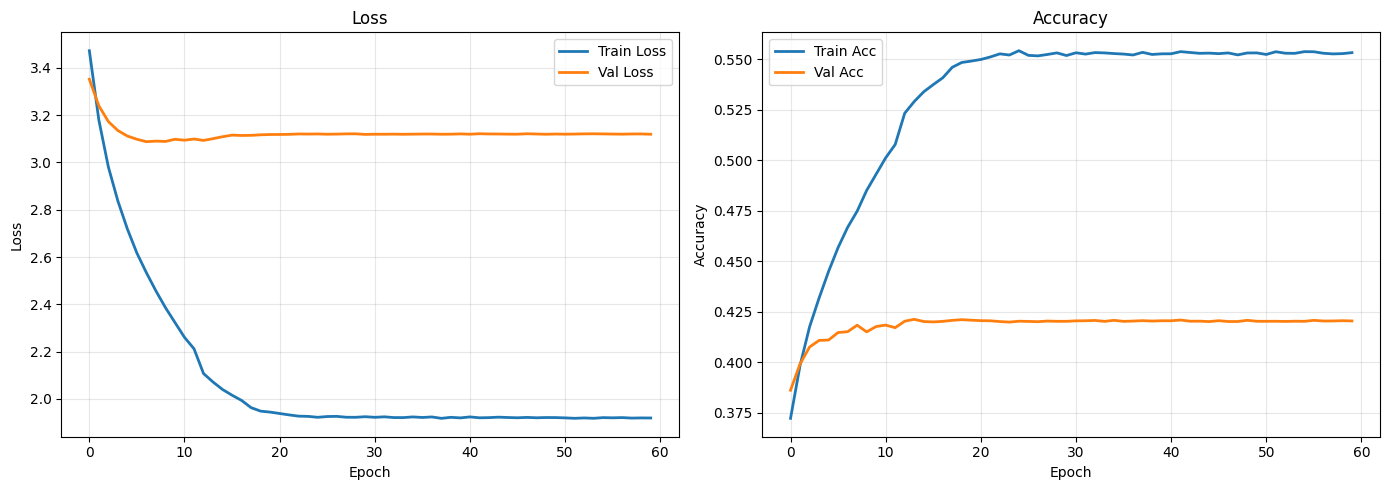

✅ Training curves saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   lw=2)
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   lw=2)
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()
print("✅ Training curves saved.")

## 15. Caption Generation (Greedy + Beam Search)

In [17]:
idx_to_word = {v: k for k, v in tokenizer.word_index.items()}


def generate_caption_greedy(model, feature, tokenizer, max_length):
    """Greedy decoding — fast, decent quality."""
    in_text = 'startseq'
    for _ in range(max_length):
        seq  = tokenizer.texts_to_sequences([in_text])[0]
        seq  = pad_sequences([seq], maxlen=max_length, padding='post')
        pred = model.predict([feature[np.newaxis], seq], verbose=0)
        word = idx_to_word.get(int(np.argmax(pred[0])), '')
        if word in ('endseq', ''):
            break
        in_text += ' ' + word
    return in_text.replace('startseq', '').strip()


def generate_caption_beam(model, feature, tokenizer, max_length, beam_width=3):
    """Beam search decoding — slower, higher quality."""
    sequences = [(['startseq'], 0.0)]

    for _ in range(max_length):
        candidates = []
        for words, score in sequences:
            if words[-1] == 'endseq':
                candidates.append((words, score))
                continue
            seq_enc    = tokenizer.texts_to_sequences([' '.join(words)])[0]
            seq_padded = pad_sequences([seq_enc], maxlen=max_length, padding='post')
            pred       = model.predict([feature[np.newaxis], seq_padded], verbose=0)[0]
            for idx in np.argsort(pred)[-beam_width:]:
                word = idx_to_word.get(int(idx), '')
                if not word:
                    continue
                new_score = score - np.log(pred[idx] + 1e-10)
                candidates.append((words + [word], new_score))
        if not candidates:
            break
        sequences = sorted(candidates, key=lambda x: x[1])[:beam_width]
        if all(s[-1] == 'endseq' for s, _ in sequences):
            break

    best = sequences[0][0]
    return ' '.join(w for w in best if w not in ('startseq', 'endseq'))


print("✅ Caption generation functions defined.")

✅ Caption generation functions defined.


## 16. Evaluate with BLEU Scores

In [18]:
def evaluate_bleu(model, test_images, captions_dict, features,
                  tokenizer, max_length, num_samples=200):
    sample_imgs  = [img for img in test_images if img in features][:num_samples]
    references   = []
    hypotheses   = []

    for img_name in tqdm(sample_imgs, desc='BLEU eval'):
        refs = [
            [t for t in cap.split() if t not in ('startseq', 'endseq')]
            for cap in captions_dict[img_name]
        ]
        references.append(refs)
        pred = generate_caption_greedy(model, features[img_name], tokenizer, max_length)
        hypotheses.append(pred.split())

    bleu1 = corpus_bleu(references, hypotheses, weights=(1,    0,    0,    0   ))
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5,  0.5,  0,    0   ))
    bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0   ))
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))

    scores = {'bleu1': bleu1, 'bleu2': bleu2, 'bleu3': bleu3, 'bleu4': bleu4}
    print(f"\n{'='*50}")
    print(f"BLEU Scores  ({len(sample_imgs)} test images)")
    for k, v in scores.items():
        print(f"  {k.upper()} : {v:.4f}")
    print('='*50)
    return scores


bleu_scores = evaluate_bleu(model, test_imgs, captions_dict, features,
                             tokenizer, MAX_LENGTH, num_samples=200)

BLEU eval: 100%|█████████████████████████████████████████████████████████████████████| 200/200 [03:19<00:00,  1.00it/s]


BLEU Scores  (200 test images)
  BLEU1 : 0.5780
  BLEU2 : 0.3966
  BLEU3 : 0.2661
  BLEU4 : 0.1726


## 17. Save All Artifacts
Saves: `final_model.h5`, `best_model.h5`, `tokenizer.pkl`, `config.json`

In [19]:
# ── 1. Final model ───────────────────────────────────────────────────────────
final_model_path = os.path.join(MODELS_DIR, 'final_model.h5')
try:
    model.save(final_model_path)
    print(f"✅ final_model.h5  saved → {final_model_path}")
except Exception as e:
    print(f"❌ Could not save final_model.h5: {e}")

# ── 2. Tokenizer ─────────────────────────────────────────────────────────────
tokenizer_path = os.path.join(OUTPUT_DIR, 'tokenizer.pkl')
try:
    with open(tokenizer_path, 'wb') as f:
        pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
    # Verification load-back
    with open(tokenizer_path, 'rb') as f:
        tok_verify = pickle.load(f)
    assert len(tok_verify.word_index) == len(tokenizer.word_index), "Tokenizer mismatch!"
    print(f"✅ tokenizer.pkl    saved → {tokenizer_path}")
    print(f"   Vocabulary size : {len(tok_verify.word_index)} words")
except Exception as e:
    print(f"❌ Could not save tokenizer.pkl: {e}")

# ── 3. Config JSON ────────────────────────────────────────────────────────────
config_path = os.path.join(OUTPUT_DIR, 'config.json')
try:
    config = {
        'model_architecture' : 'EfficientNetB0 + BiLSTM + Attention',
        'tokenizer_type'     : 'SimpleTokenizer (Keras 3.x compatible)',
        'learning_rate_schedule': 'Cosine Annealing + ReduceLROnPlateau',
        'vocab_size'         : int(VOCAB_SIZE),
        'max_length'         : int(MAX_LENGTH),
        'img_size'           : IMG_SIZE,
        'feature_dim'        : FEATURE_DIM,
        'embed_dim'          : EMBED_DIM,
        'lstm_units'         : LSTM_UNITS,
        'dense_units'        : DENSE_UNITS,
        'dropout_rate'       : DROPOUT_RATE,
        'batch_size'         : BATCH_SIZE,
        'epochs_trained'     : len(history.history['loss']),
        'final_train_loss'   : float(history.history['loss'][-1]),
        'final_val_loss'     : float(history.history['val_loss'][-1]),
        'final_train_acc'    : float(history.history['accuracy'][-1]),
        'final_val_acc'      : float(history.history['val_accuracy'][-1]),
        'best_val_acc'       : float(max(history.history['val_accuracy'])),
        'best_val_loss'      : float(min(history.history['val_loss'])),
        'bleu_scores'        : bleu_scores,
        'saved_artifacts'    : {
            'final_model'  : final_model_path,
            'best_model'   : os.path.join(MODELS_DIR, 'best_model.h5'),
            'tokenizer'    : tokenizer_path,
            'config'       : config_path,
        }
    }
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"✅ config.json      saved → {config_path}")
except Exception as e:
    print(f"❌ Could not save config.json: {e}")

print("\n📦 All artifacts saved.")

✅ final_model.h5  saved → C:\Users\Rehan\Documents\topic-model\caption_outputs\models\final_model.h5
✅ tokenizer.pkl    saved → C:\Users\Rehan\Documents\topic-model\caption_outputs\tokenizer.pkl
   Vocabulary size : 8109 words
✅ config.json      saved → C:\Users\Rehan\Documents\topic-model\caption_outputs\config.json

📦 All artifacts saved.


## 18. Visual Test — Sample Predictions

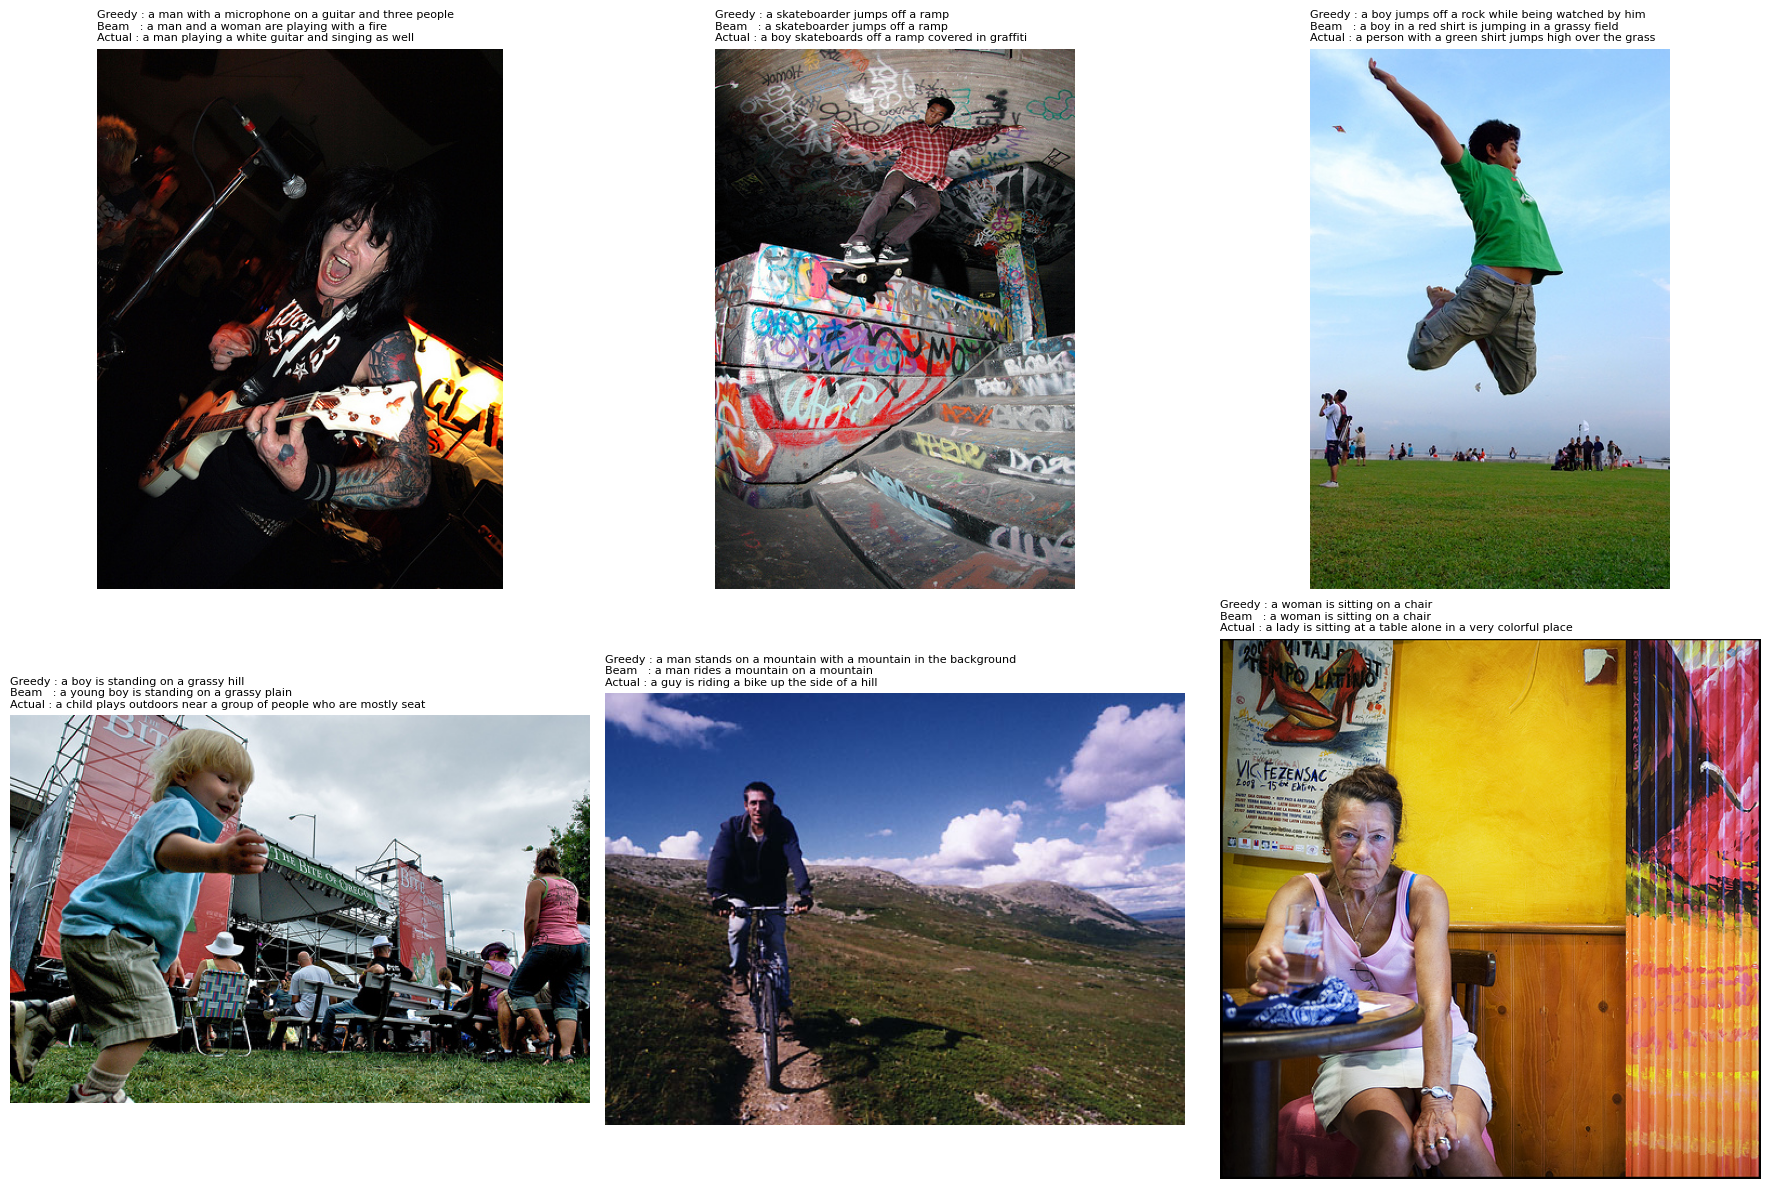

✅ sample_predictions.png saved.


In [20]:
def visualize_predictions(model, test_images, captions_dict, features,
                          tokenizer, max_length, n=6):
    sample = [img for img in test_images if img in features][:n]
    if not sample:
        print("❌ No test images found in features!")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, img_name in enumerate(sample):
        img_path = os.path.join(IMAGE_DIR, img_name)
        if not os.path.exists(img_path):
            print(f"⚠️  Not found: {img_path}")
            continue

        greedy_cap = generate_caption_greedy(model, features[img_name],
                                             tokenizer, max_length)
        beam_cap   = generate_caption_beam(model, features[img_name],
                                           tokenizer, max_length, beam_width=3)
        orig = captions_dict[img_name][0]
        orig = orig.replace('startseq', '').replace('endseq', '').strip()

        axes[i].imshow(plt.imread(img_path))
        axes[i].axis('off')
        axes[i].set_title(
            f"Greedy : {greedy_cap[:65]}\nBeam   : {beam_cap[:65]}\nActual : {orig[:65]}",
            fontsize=8, loc='left'
        )

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sample_predictions.png'), dpi=150)
    plt.show()
    print("✅ sample_predictions.png saved.")


if features and test_imgs:
    try:
        visualize_predictions(model, test_imgs, captions_dict, features,
                              tokenizer, MAX_LENGTH, n=6)
    except Exception as e:
        print(f"❌ Visualisation error: {e}")
else:
    print("⚠️  Cannot visualise — missing features or test images.")

## 19. Predict on a Custom / New Image

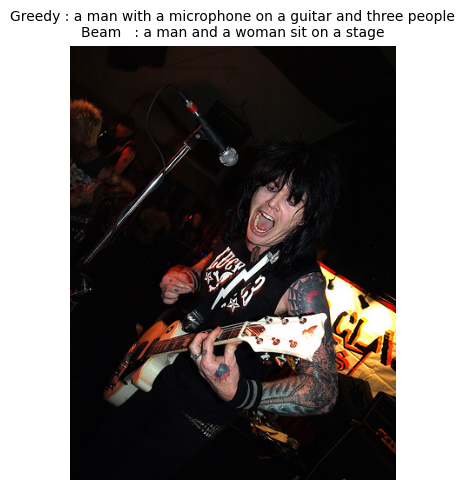

Greedy : a man with a microphone on a guitar and three people
Beam   : a man and a woman sit on a stage


In [21]:
def predict_custom_image(image_path, model, feature_extractor, tokenizer, max_length):
    """Generate caption for any image not in the training set."""
    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return None

    img   = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr   = preprocess_input(img_to_array(img)[np.newaxis])
    feat  = feature_extractor.predict(arr, verbose=0).flatten()

    greedy = generate_caption_greedy(model, feat, tokenizer, max_length)
    beam   = generate_caption_beam(model, feat, tokenizer, max_length, beam_width=5)

    plt.figure(figsize=(7, 5))
    plt.imshow(plt.imread(image_path))
    plt.axis('off')
    plt.title(f"Greedy : {greedy}\nBeam   : {beam}", fontsize=10)
    plt.tight_layout()
    plt.show()
    return {'greedy': greedy, 'beam': beam}


# ── Quick test with first available test image ──────────────────────────────
avail = [img for img in test_imgs if img in features]
if avail:
    result = predict_custom_image(
        os.path.join(IMAGE_DIR, avail[0]),
        model, feature_extractor, tokenizer, MAX_LENGTH
    )
    if result:
        print(f"Greedy : {result['greedy']}")
        print(f"Beam   : {result['beam']}")
else:
    print("⚠️  No test images in features cache.")

# ── To test YOUR OWN image, uncomment: ───────────────────────────────────────
# result = predict_custom_image(
#     r'C:\path\to\your\image.jpg',
#     model, feature_extractor, tokenizer, MAX_LENGTH
# )

## 20. Model Summary Report

In [22]:
print('=' * 65)
print('          IMAGE CAPTION MODEL — TRAINING SUMMARY')
print('=' * 65)
print(f"Architecture  : EfficientNetB0 (frozen) + BiLSTM + Attention")
print(f"Image size    : {IMG_SIZE}×{IMG_SIZE}    Feature dim : {FEATURE_DIM}")
print(f"Embed dim     : {EMBED_DIM}    LSTM units : {LSTM_UNITS}")
print(f"Vocabulary    : {VOCAB_SIZE}   Max length  : {MAX_LENGTH}")
print(f"Dropout       : {DROPOUT_RATE}     GPU        : {bool(gpus)}")
print()
print(f"Dataset:")
print(f"  Total images : {len(captions_dict)}")
print(f"  Train        : {len(train_imgs)}")
print(f"  Val          : {len(val_imgs)}")
print(f"  Test         : {len(test_imgs)}")
print()
print(f"Training:")
print(f"  Epochs run   : {len(history.history['loss'])}")
print(f"  Best val acc : {max(history.history['val_accuracy']):.4f}")
print(f"  Best val loss: {min(history.history['val_loss']):.4f}")
print(f"  Final train acc : {history.history['accuracy'][-1]:.4f}")
print(f"  Final val acc   : {history.history['val_accuracy'][-1]:.4f}")
print()
print("BLEU Scores:")
for k, v in bleu_scores.items():
    print(f"  {k.upper()} : {v:.4f}")
print()
print("Saved files:")
print(f"  {os.path.join(MODELS_DIR, 'final_model.h5')}")
print(f"  {os.path.join(MODELS_DIR, 'best_model.h5')}")
print(f"  {os.path.join(OUTPUT_DIR,  'tokenizer.pkl')}")
print(f"  {os.path.join(OUTPUT_DIR,  'config.json')}")
print(f"  {os.path.join(OUTPUT_DIR,  'training_curves.png')}")
print('=' * 65)

          IMAGE CAPTION MODEL — TRAINING SUMMARY
Architecture  : EfficientNetB0 (frozen) + BiLSTM + Attention
Image size    : 224×224    Feature dim : 1280
Embed dim     : 512    LSTM units : 512
Vocabulary    : 8110   Max length  : 17
Dropout       : 0.3     GPU        : True

Dataset:
  Total images : 8089
  Train        : 6471
  Val          : 809
  Test         : 809

Training:
  Epochs run   : 60
  Best val acc : 0.4212
  Best val loss: 3.0878
  Final train acc : 0.5534
  Final val acc   : 0.4204

BLEU Scores:
  BLEU1 : 0.5780
  BLEU2 : 0.3966
  BLEU3 : 0.2661
  BLEU4 : 0.1726

Saved files:
  C:\Users\Rehan\Documents\topic-model\caption_outputs\models\final_model.h5
  C:\Users\Rehan\Documents\topic-model\caption_outputs\models\best_model.h5
  C:\Users\Rehan\Documents\topic-model\caption_outputs\tokenizer.pkl
  C:\Users\Rehan\Documents\topic-model\caption_outputs\config.json
  C:\Users\Rehan\Documents\topic-model\caption_outputs\training_curves.png
